# Introduction

This notebook is aimed to help in post-processing Markov chain Monte Carlo outputs.

It implements basic steps of the MCMC chain analysis, that can be followd to understand
if the posterior sampling has gone well. In particular, this notebook is used to:

- understand chain convergence 
- compute statistical quantities of the chain
- plot basic results

We suggest to run the MCMC chains with burn_in=0 and thin=1, to 
have full control of the output. 

The notebook will read the output of the CosmoBolognaLib posterior sampling.

For a similar example, have a look at the emcee page: http://dfm.io/emcee/current/user/line/

In [6]:
# to ensure compatibility in Python versions 2.x and 3.x
from __future__ import print_function

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

# Run the CosmoBolognaLib ./fit example

In [7]:
#This is (of course) not mandatory. Here is done to have some example chain to plot.
os.system("make fit && ./fit")

g++ -std=c++17 -fopenmp  -O3 -unroll -Wall -Wextra -pedantic -Wfatal-errors -Werror -I/Users/arun/include/ -I/Users/arun/dev/CosmoBolognaLib/Examples/statistics/codes/../../../Headers/ -I/Users/arun/dev/CosmoBolognaLib/Examples/statistics/codes/../../../External/Cuba-4.2.1/ -I/Users/arun/dev/CosmoBolognaLib/Examples/statistics/codes/../../../External/Eigen/eigen-3.4.0/ -I/Users/arun/dev/CosmoBolognaLib/Examples/statistics/codes/../../../External/CCfits/include  -c fit.cpp


clang++: fatal error: unsupported option '-fopenmp'
make: *** [fit.o] Error 1


512

# Read the MCMC output

The basic inputs nedeed are the following:

- the chain file
- the directory where it is stored

In [8]:
inputDir = "../output/"
inputFilePar = "chains_linear_relation_parameters.dat"
inputFile = "chains_linear_relation_chain.dat"

Read all the columns of the table:

- the first column is the step number, the last three columns are the values of the log likelihood, the log prior and the log posterior

- all the other columns are the parameters, whose names are inferred from the header file 

- fixed parameters are identified as the ones with null standard deviation; there is currently no way 
  (and maybe there is no need) to recognize derived parameters

In [9]:
table = np.genfromtxt(inputDir+inputFile, unpack=True)

nPar = len(table)-4

FileNotFoundError: ../output/chains_linear_relation_chain.dat not found.

In [10]:
ff = open(inputDir+inputFilePar, "r")

ff.readline()

isFree = [True]*nPar
nParEff = 0
names = [""]*(nPar+4)
names[0] = "Step"
names[-1] = "Log(Posterior)"
names[-2] = "Log(Prior)"
names[-3] = "Log(Likelihood)"
for i in range(nPar):
    ll = ff.readline()
    if "FREE" in ll:
        names[i+1] = ll[0:ll.index("FREE")]
        nParEff += 1
    if "FIXED" in ll:
        names[i+1] = ll[0:ll.index("FIXED")]
        isFree[i] = False

FileNotFoundError: [Errno 2] No such file or directory: '../output/chains_linear_relation_parameters.dat'

## Plot the chains

By plotting the chains you should be able to roughly identified the step
at which chains are converged. This should be used below as burn in.

In [11]:
gs = gridspec.GridSpec(nPar+3, 2)

figure = plt.figure(figsize=(20, 3*(nPar+3)))

for i in range(nPar):
    ax = figure.add_subplot(gs[i, 0])
    label = "Free"
    color = "b"
    if (isFree[i]==False):
        label="Fixed"
        color = "r"
    ax.plot(table[0], table[i+1], '.k', ms=0.5, color=color, label=label)
    ax.set_ylabel(names[i+1])
    ax.legend(loc="lower right")

for i in range(nPar, nPar+3):
    ax = figure.add_subplot(gs[i, 0])
    ax.plot(table[0], table[i+1], '.k', ms=0.5)
    ax.set_ylabel(names[i+1])
    if (i==nPar+2):
        ax.set_xlabel("Step")

NameError: name 'nPar' is not defined

# Cut the chains

Here will be inserted some convergence criteria to choose automatically 
an appropriate value for the burn in.

In the meanwhile the value of the burn in should be changed manually.

The thin parameter should be changed as weel, if you only want to store and yield every "thin" samples in the chain.

In [7]:
#Here will be inserted some criteria to choose automatically 
#an appropriate value for the burn in, meanwhile...
burn_in = 2000
thin = 1

In [8]:
#cut the table
new_table = table[:,burn_in:-1:thin]
nPt = len(new_table[0])

# Fundamental quantities

The following is used to compute fundamental quantities to characterize parameter posterior distributions.

In [9]:
for i in range(nPar):
    print ("\nParameter %s:"%names[i+1])
    tt = "Free"
    if not isFree[i]:
        print ("Type: Fixed")
        print ("Value = %s"%np.mean(new_table[i+1]))
    else:
        print ("Type: Free")
        print ("Mean = %s"%np.mean(new_table[i+1]))
        print ("Std = %s"%np.std(new_table[i+1]))
        print ("Median = %s"%np.median(new_table[i+1]))
        print ("16-th percentile = %s"%np.percentile(new_table[i+1], 16))
        print ("84-th percentile = %s"%np.percentile(new_table[i+1], 84))


Parameter A :
Type: Free
Mean = 0.9850552621929624
Std = 0.1093726755674374
Median = 0.98538
16-th percentile = 0.87385
84-th percentile = 1.09391

Parameter B :
Type: Free
Mean = 1.8418482143377986
Std = 0.67556864082943
Median = 1.83816
16-th percentile = 1.1697172
84-th percentile = 2.5141204

Parameter C :
Type: Fixed
Value = 1.0

Parameter D :
Type: Free
Mean = 3.826903493406113
Std = 0.5810673229928675
Median = 3.82435
16-th percentile = 3.244768
84-th percentile = 4.40876

Parameter :
Type: Free
Mean = -1.195498912685681
Std = 0.982424854471264
Median = -0.90391
16-th percentile = -2.0102244
84-th percentile = -0.37996


# Corner plot

Print the corner plot of the MCMC results

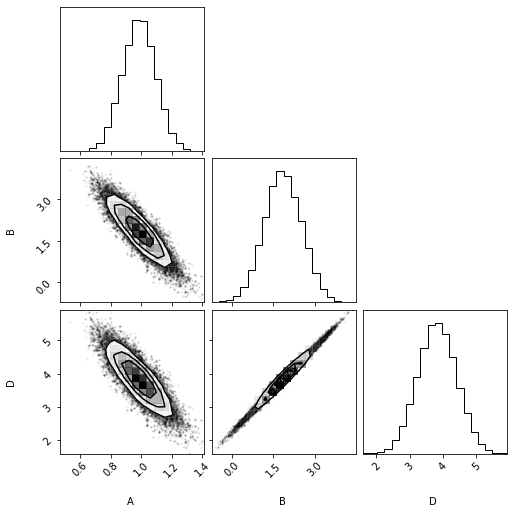

In [10]:
try:
    import corner
except ImportError:
    print ("This piece of the notebook requires the corner.py package.")
    print ("Please install it if you are interested in producing corner plots")
    print ("https://corner.readthedocs.io/en/latest/pages/custom.html")
    pass

#Create the corner plot.
#Disclaimer, for simplicity the fixed parameters are thrown away
samples = np.zeros(shape=(nParEff, nPt))
labels = [""]*nParEff

n = 0
for i in range(nPar-1):
    if isFree[i]:
        samples[n] = new_table[i+1]
        labels[n] = names[i+1]
        n += 1

figure = corner.corner(samples.T, labels=labels)